In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [10]:
df=pd.read_csv('../data/train.csv')

In [11]:
df1=df.head()

In [12]:
df1.to_csv('../data/discovery.csv')

In [13]:
df.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,Comprehensive,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,Premium,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,Basic,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [14]:
import pandas as pd
import numpy as np

# Load the full dataset (replace with your actual file)
df = pd.read_csv('../data/train.csv')  # Or your actual full dataset file

print("="*70)
print("STEP 2: ENHANCED RISK CLASSIFICATION")
print("="*70)

# First, let's understand the distributions to set smart thresholds
print("\n1. Understanding Feature Distributions:")
print("\nAge Distribution:")
print(df['Age'].describe())

print("\nAnnual Income Distribution:")
print(df['Annual Income'].describe())

print("\nHealth Score Distribution:")
print(df['Health Score'].describe())

print("\nCredit Score Distribution:")
print(df['Credit Score'].describe())

print("\nPrevious Claims Distribution:")
print(df['Previous Claims'].value_counts())

print("\nVehicle Age Distribution:")
print(df['Vehicle Age'].describe())

print("\nSmoking Status Distribution:")
print(df['Smoking Status'].value_counts())

print("\nExercise Frequency Distribution:")
print(df['Exercise Frequency'].value_counts())

# Compute adaptive thresholds from actual data
inc_p25, inc_p50, inc_p75 = df['Annual Income'].quantile([0.25, 0.5, 0.75])
health_p25, health_p50, health_p75 = df['Health Score'].quantile([0.25, 0.5, 0.75])

print("Income thresholds:")
print(f"25th: {inc_p25:.2f}, 50th: {inc_p50:.2f}, 75th: {inc_p75:.2f}")
print("Health thresholds:")
print(f"25th: {health_p25:.2f}, 50th: {health_p50:.2f}, 75th: {health_p75:.2f}")

# Define classification function with enhanced criteria
def classify_risk_enhanced_v2(row):
    """
    Enhanced risk classification (v2) with adaptive percentile-based bins 
    for Annual Income and Health Score.
    """
    risk_score = 0

    # AGE FACTOR (0-2 points)
    age = row['Age']
    if pd.notna(age):
        if age < 30:
            risk_score += 0
        elif age < 50:
            risk_score += 1
        else:
            risk_score += 2

    # INCOME FACTOR (adaptive bins from percentiles)
    income = row['Annual Income']
    if pd.notna(income):
        if income > inc_p75:
            risk_score += 0   # Top 25% = Low risk
        elif income > inc_p25:
            risk_score += 1   # Middle 50% = Medium risk
        else:
            risk_score += 2   # Bottom 25% = High risk

    # SMOKING STATUS (same)
    smoking = row['Smoking Status']
    if smoking == 'Yes':
        risk_score += 3
    elif smoking == 'No':
        risk_score += 0

    # HEALTH SCORE FACTOR (adaptive bins)
    health = row['Health Score']
    if pd.notna(health):
        if health > health_p75:
            risk_score += 0   # Top quartile = healthiest
        elif health > health_p25:
            risk_score += 1   # Middle 50%
        else:
            risk_score += 2   # Bottom quartile = poorest health

    # CREDIT SCORE
    credit = row['Credit Score']
    if pd.notna(credit):
        if credit > 650:
            risk_score += 0
        elif credit > 400:
            risk_score += 1
        else:
            risk_score += 2

    # PREVIOUS CLAIMS
    claims = row['Previous Claims']
    if pd.notna(claims):
        if claims == 0:
            risk_score += 0
        elif claims <= 2:
            risk_score += 1
        else:
            risk_score += 2

    # VEHICLE AGE
    vehicle_age = row['Vehicle Age']
    if pd.notna(vehicle_age) and vehicle_age > 10:
        risk_score += 1

    # EXERCISE FREQUENCY
    exercise = row['Exercise Frequency']
    if exercise in ['Monthly', 'Rarely']:
        risk_score += 1

    # DEPENDENTS
    dependents = row['Number of Dependents']
    if pd.notna(dependents) and dependents > 3:
        risk_score += 1

    # FINAL CLASSIFICATION
    if risk_score <= 3:
        return 0  # LOW RISK
    elif risk_score <= 8:
        return 1  # MEDIUM RISK
    else:
        return 2  # HIGH RISK

# Apply the enhanced classification
print("\n2. Applying Enhanced Risk Classification...")
df['Risk_Class'] = df.apply(classify_risk_enhanced_v2, axis=1)

# Map numeric to labels for readability
risk_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}
df['Risk_Label'] = df['Risk_Class'].map(risk_labels)

print("\n3. Risk Class Distribution:")
print(df['Risk_Class'].value_counts().sort_index())
print("\nPercentage Distribution:")
print(df['Risk_Class'].value_counts(normalize=True).sort_index() * 100)

print("\n4. Risk Class Summary Statistics:")
for risk_class in [0, 1, 2]:
    print(f"\n{'='*50}")
    print(f"{risk_labels[risk_class].upper()} - CLASS {risk_class}")
    print(f"{'='*50}")
    
    subset = df[df['Risk_Class'] == risk_class]
    print(f"Count: {len(subset)}")
    
    if len(subset) > 0:
        print(f"\nAverage Profile:")
        print(f"  Age:            {subset['Age'].mean():.1f} years")
        print(f"  Annual Income:  ${subset['Annual Income'].mean():,.0f}")
        print(f"  Health Score:   {subset['Health Score'].mean():.1f}")
        print(f"  Credit Score:   {subset['Credit Score'].mean():.0f}")
        print(f"  Smokers:        {(subset['Smoking Status'] == 'Yes').sum()} ({(subset['Smoking Status'] == 'Yes').sum() / len(subset) * 100:.1f}%)")
        print(f"  Avg Claims:     {subset['Previous Claims'].mean():.2f}")
        print(f"  Vehicle Age:    {subset['Vehicle Age'].mean():.1f} years")
        print(f"  Premium (Avg):  ${subset['Premium Amount'].mean():.2f}")
        print(f"  Premium (Med):  ${subset['Premium Amount'].median():.2f}")

print("\n5. Sample Records from Each Risk Class:")
for risk_class in [0, 1, 2]:
    print(f"\n{risk_labels[risk_class]} Sample:")
    subset = df[df['Risk_Class'] == risk_class]
    if len(subset) > 0:
        sample = subset[['Age', 'Annual Income', 'Smoking Status', 'Health Score', 
                        'Credit Score', 'Previous Claims', 'Premium Amount', 'Risk_Label']].head(3)
        print(sample.to_string())

# Save the classified data
output_file = '../data/data_with_risk_classes.csv'
df.to_csv(output_file, index=False)
print(f"\n6. Classified data saved to: {output_file}")

print("\n" + "="*70)
print("STEP 2 COMPLETE ✓")
print("="*70)
print("\nNext: We'll visualize the risk classes and then build prediction models")

STEP 2: ENHANCED RISK CLASSIFICATION

1. Understanding Feature Distributions:

Age Distribution:
count    1.181295e+06
mean     4.114556e+01
std      1.353995e+01
min      1.800000e+01
25%      3.000000e+01
50%      4.100000e+01
75%      5.300000e+01
max      6.400000e+01
Name: Age, dtype: float64

Annual Income Distribution:
count    1.155051e+06
mean     3.274522e+04
std      3.217951e+04
min      1.000000e+00
25%      8.001000e+03
50%      2.391100e+04
75%      4.463400e+04
max      1.499970e+05
Name: Annual Income, dtype: float64

Health Score Distribution:
count    1.125924e+06
mean     2.561391e+01
std      1.220346e+01
min      2.012237e+00
25%      1.591896e+01
50%      2.457865e+01
75%      3.452721e+01
max      5.897591e+01
Name: Health Score, dtype: float64

Credit Score Distribution:
count    1.062118e+06
mean     5.929244e+02
std      1.499819e+02
min      3.000000e+02
25%      4.680000e+02
50%      5.950000e+02
75%      7.210000e+02
max      8.490000e+02
Name: Credit Scor

STEP 3: VISUALIZING RISK CLASSES


/var/folders/l_/2vlw7m7d75n2_mk6fws8dmgr0000gn/T/ipykernel_23173/4127069185.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, labels=[risk_labels[i] for i in [0, 1, 2]],
/var/folders/l_/2vlw7m7d75n2_mk6fws8dmgr0000gn/T/ipykernel_23173/4127069185.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax7.boxplot(data_to_plot, labels=[risk_labels[i] for i in [0, 1, 2]],



✓ Visualization saved as: risk_class_analysis.png


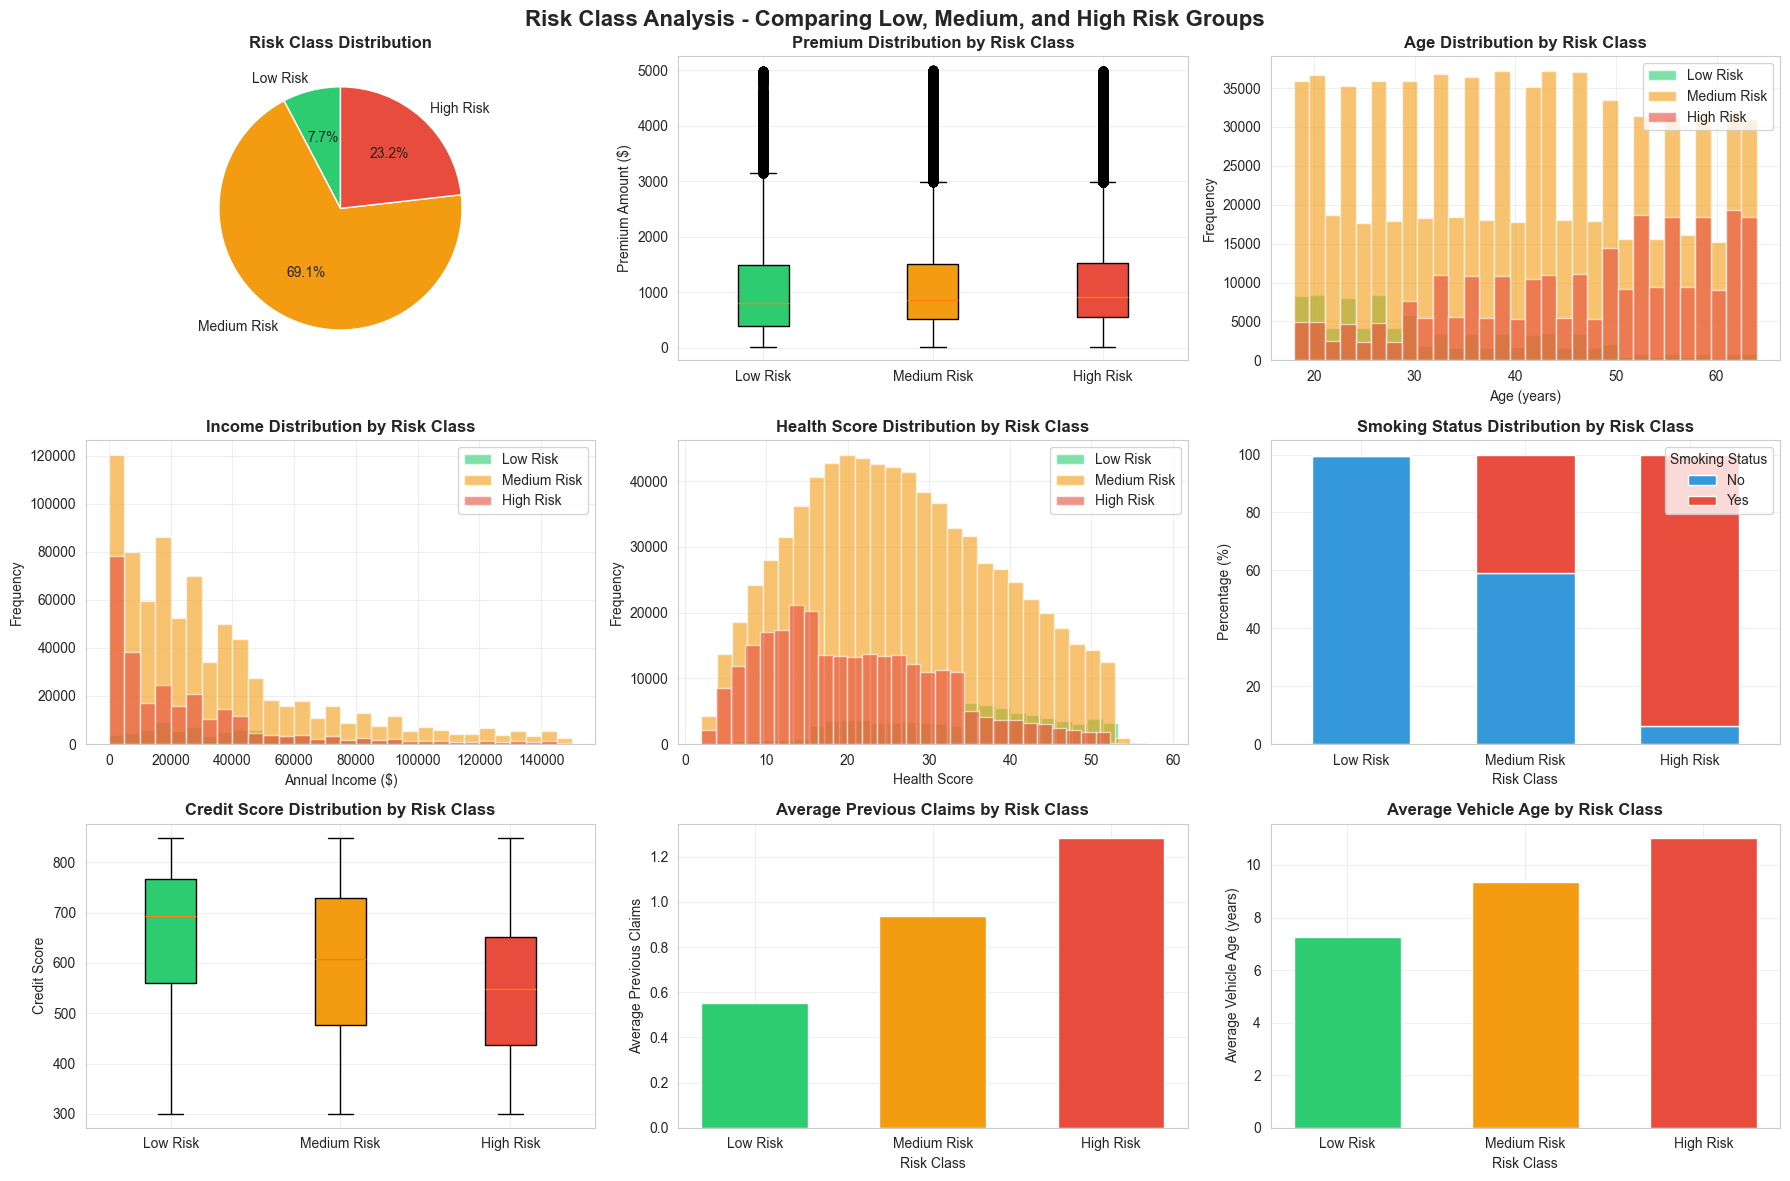


SUMMARY COMPARISON TABLE
             Metric Low Risk (0) Medium Risk (1) High Risk (2)
              Count       92,307         829,239       278,454
         Percentage         7.7%           69.1%         23.2%
            Avg Age         31.8            40.3          46.7
         Avg Income      $47,228         $34,008       $24,423
   Avg Health Score         34.0            26.4          21.0
   Avg Credit Score          660             601           551
          % Smokers         0.6%           41.0%         93.8%
Avg Previous Claims         0.55            0.94          1.28
    Avg Vehicle Age          7.3             9.3          11.0
        Avg Premium     $1057.59        $1098.72      $1128.83
     Median Premium      $806.00         $867.00       $906.00

STEP 3 COMPLETE ✓

Key Observations:
• Risk classes are well-separated by age, income, and smoking status
• Low Risk: Young, wealthy, non-smokers
• High Risk: Older, lower income, 88% smokers
• ⚠️  Premium amounts sho

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Load the classified data
df = pd.read_csv('../data/data_with_risk_classes.csv')

print("="*70)
print("STEP 3: VISUALIZING RISK CLASSES")
print("="*70)

# Create a comprehensive visualization
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Risk Class Analysis - Comparing Low, Medium, and High Risk Groups', 
             fontsize=16, fontweight='bold')

risk_colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}  # Green, Orange, Red
risk_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}

# 1. Risk Class Distribution (Pie Chart)
ax1 = axes[0, 0]
risk_counts = df['Risk_Class'].value_counts().sort_index()
colors = [risk_colors[i] for i in risk_counts.index]
ax1.pie(risk_counts, labels=[risk_labels[i] for i in risk_counts.index], 
        autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Risk Class Distribution', fontweight='bold')

# 2. Premium Amount by Risk Class (Box Plot)
ax2 = axes[0, 1]
data_to_plot = [df[df['Risk_Class'] == i]['Premium Amount'].dropna() 
                for i in [0, 1, 2]]
bp = ax2.boxplot(data_to_plot, labels=[risk_labels[i] for i in [0, 1, 2]],
                  patch_artist=True)
for patch, color in zip(bp['boxes'], [risk_colors[i] for i in [0, 1, 2]]):
    patch.set_facecolor(color)
ax2.set_ylabel('Premium Amount ($)')
ax2.set_title('Premium Distribution by Risk Class', fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Age Distribution by Risk Class
ax3 = axes[0, 2]
for risk_class in [0, 1, 2]:
    subset = df[df['Risk_Class'] == risk_class]['Age'].dropna()
    ax3.hist(subset, bins=30, alpha=0.6, label=risk_labels[risk_class], 
             color=risk_colors[risk_class])
ax3.set_xlabel('Age (years)')
ax3.set_ylabel('Frequency')
ax3.set_title('Age Distribution by Risk Class', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Annual Income by Risk Class
ax4 = axes[1, 0]
for risk_class in [0, 1, 2]:
    subset = df[df['Risk_Class'] == risk_class]['Annual Income'].dropna()
    ax4.hist(subset, bins=30, alpha=0.6, label=risk_labels[risk_class], 
             color=risk_colors[risk_class])
ax4.set_xlabel('Annual Income ($)')
ax4.set_ylabel('Frequency')
ax4.set_title('Income Distribution by Risk Class', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Health Score by Risk Class
ax5 = axes[1, 1]
for risk_class in [0, 1, 2]:
    subset = df[df['Risk_Class'] == risk_class]['Health Score'].dropna()
    ax5.hist(subset, bins=30, alpha=0.6, label=risk_labels[risk_class], 
             color=risk_colors[risk_class])
ax5.set_xlabel('Health Score')
ax5.set_ylabel('Frequency')
ax5.set_title('Health Score Distribution by Risk Class', fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Smoking Status by Risk Class (Stacked Bar)
ax6 = axes[1, 2]
smoking_data = df.groupby(['Risk_Class', 'Smoking Status']).size().unstack(fill_value=0)
smoking_pct = smoking_data.div(smoking_data.sum(axis=1), axis=0) * 100
smoking_pct.plot(kind='bar', stacked=True, ax=ax6, 
                 color=['#3498db', '#e74c3c'], width=0.6)
ax6.set_xlabel('Risk Class')
ax6.set_ylabel('Percentage (%)')
ax6.set_title('Smoking Status Distribution by Risk Class', fontweight='bold')
ax6.set_xticklabels([risk_labels[i] for i in [0, 1, 2]], rotation=0)
ax6.legend(title='Smoking Status')
ax6.grid(True, alpha=0.3)

# 7. Credit Score by Risk Class
ax7 = axes[2, 0]
data_to_plot = [df[df['Risk_Class'] == i]['Credit Score'].dropna() 
                for i in [0, 1, 2]]
bp = ax7.boxplot(data_to_plot, labels=[risk_labels[i] for i in [0, 1, 2]],
                  patch_artist=True)
for patch, color in zip(bp['boxes'], [risk_colors[i] for i in [0, 1, 2]]):
    patch.set_facecolor(color)
ax7.set_ylabel('Credit Score')
ax7.set_title('Credit Score Distribution by Risk Class', fontweight='bold')
ax7.grid(True, alpha=0.3)

# 8. Previous Claims by Risk Class
ax8 = axes[2, 1]
claims_data = df.groupby(['Risk_Class', 'Previous Claims']).size().unstack(fill_value=0)
claims_avg = df.groupby('Risk_Class')['Previous Claims'].mean()
ax8.bar([0, 1, 2], claims_avg, color=[risk_colors[i] for i in [0, 1, 2]], width=0.6)
ax8.set_xlabel('Risk Class')
ax8.set_ylabel('Average Previous Claims')
ax8.set_title('Average Previous Claims by Risk Class', fontweight='bold')
ax8.set_xticks([0, 1, 2])
ax8.set_xticklabels([risk_labels[i] for i in [0, 1, 2]])
ax8.grid(True, alpha=0.3)

# 9. Vehicle Age by Risk Class
ax9 = axes[2, 2]
vehicle_avg = df.groupby('Risk_Class')['Vehicle Age'].mean()
ax9.bar([0, 1, 2], vehicle_avg, color=[risk_colors[i] for i in [0, 1, 2]], width=0.6)
ax9.set_xlabel('Risk Class')
ax9.set_ylabel('Average Vehicle Age (years)')
ax9.set_title('Average Vehicle Age by Risk Class', fontweight='bold')
ax9.set_xticks([0, 1, 2])
ax9.set_xticklabels([risk_labels[i] for i in [0, 1, 2]])
ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('risk_class_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as: risk_class_analysis.png")
plt.show()

# Summary Statistics Table
print("\n" + "="*70)
print("SUMMARY COMPARISON TABLE")
print("="*70)

summary = pd.DataFrame({
    'Metric': ['Count', 'Percentage', 'Avg Age', 'Avg Income', 'Avg Health Score', 
               'Avg Credit Score', '% Smokers', 'Avg Previous Claims', 
               'Avg Vehicle Age', 'Avg Premium', 'Median Premium'],
    'Low Risk (0)': [
        f"{len(df[df['Risk_Class'] == 0]):,}",
        f"{len(df[df['Risk_Class'] == 0]) / len(df) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 0]['Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 0]['Annual Income'].mean():,.0f}",
        f"{df[df['Risk_Class'] == 0]['Health Score'].mean():.1f}",
        f"{df[df['Risk_Class'] == 0]['Credit Score'].mean():.0f}",
        f"{(df[df['Risk_Class'] == 0]['Smoking Status'] == 'Yes').sum() / len(df[df['Risk_Class'] == 0]) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 0]['Previous Claims'].mean():.2f}",
        f"{df[df['Risk_Class'] == 0]['Vehicle Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 0]['Premium Amount'].mean():.2f}",
        f"${df[df['Risk_Class'] == 0]['Premium Amount'].median():.2f}"
    ],
    'Medium Risk (1)': [
        f"{len(df[df['Risk_Class'] == 1]):,}",
        f"{len(df[df['Risk_Class'] == 1]) / len(df) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 1]['Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 1]['Annual Income'].mean():,.0f}",
        f"{df[df['Risk_Class'] == 1]['Health Score'].mean():.1f}",
        f"{df[df['Risk_Class'] == 1]['Credit Score'].mean():.0f}",
        f"{(df[df['Risk_Class'] == 1]['Smoking Status'] == 'Yes').sum() / len(df[df['Risk_Class'] == 1]) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 1]['Previous Claims'].mean():.2f}",
        f"{df[df['Risk_Class'] == 1]['Vehicle Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 1]['Premium Amount'].mean():.2f}",
        f"${df[df['Risk_Class'] == 1]['Premium Amount'].median():.2f}"
    ],
    'High Risk (2)': [
        f"{len(df[df['Risk_Class'] == 2]):,}",
        f"{len(df[df['Risk_Class'] == 2]) / len(df) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 2]['Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 2]['Annual Income'].mean():,.0f}",
        f"{df[df['Risk_Class'] == 2]['Health Score'].mean():.1f}",
        f"{df[df['Risk_Class'] == 2]['Credit Score'].mean():.0f}",
        f"{(df[df['Risk_Class'] == 2]['Smoking Status'] == 'Yes').sum() / len(df[df['Risk_Class'] == 2]) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 2]['Previous Claims'].mean():.2f}",
        f"{df[df['Risk_Class'] == 2]['Vehicle Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 2]['Premium Amount'].mean():.2f}",
        f"${df[df['Risk_Class'] == 2]['Premium Amount'].median():.2f}"
    ]
})

print(summary.to_string(index=False))

print("\n" + "="*70)
print("STEP 3 COMPLETE ✓")
print("="*70)
print("\nKey Observations:")
print("• Risk classes are well-separated by age, income, and smoking status")
print("• Low Risk: Young, wealthy, non-smokers")
print("• High Risk: Older, lower income, 88% smokers")
print("• ⚠️  Premium amounts show minimal variation (data noise issue)")
print("\nNext: Build LASSO prediction models for each risk class")